# Logistic Regression

## Overview

Models the probability of a binary outcome as a function of predictors. The model is linear on the log-odds scale; outputs are converted to probabilities via the logistic function.

**Key outputs:**

| Output | Interpretation |
|---|---|
| Log-odds coefficient | Additive effect on log-odds scale |
| Odds ratio (exp(coef)) | Multiplicative effect on odds |
| Predicted probability | P(outcome=1) for given predictor values |
| AUC-ROC | Overall discriminative ability (0.5=chance, 1=perfect) |

Always report predicted probabilities and absolute risk differences alongside odds ratios — ORs alone are easily misinterpreted.

---

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import roc_curve, roc_auc_score, classification_report
from scipy.special import expit  # sigmoid / logistic function

rng = np.random.default_rng(42)
n = 200
elevation = rng.uniform(50, 400, n)
nitrate   = rng.gamma(2, 2, n)
treatment = rng.choice([0,1], n)
# True log-odds: restoration and low nitrate increase survival probability
log_odds = -1.5 + 0.003*elevation - 0.15*nitrate + 1.2*treatment
prob = expit(log_odds)
outcome = rng.binomial(1, prob)
df = pd.DataFrame({"outcome":outcome,"elevation":elevation,
                   "nitrate":nitrate,"treatment":treatment})
print(f"Outcome prevalence: {outcome.mean():.3f}")

Outcome prevalence: 0.300


---
## Fitting with statsmodels

In [13]:
X = sm.add_constant(df[["elevation","nitrate","treatment"]])
model = sm.Logit(df["outcome"], X).fit()
print(model.summary())
# Odds ratios with CIs
or_df = pd.DataFrame({
    "OR":   np.exp(model.params),
    "CI_lo":np.exp(model.conf_int()[0]),
    "CI_hi":np.exp(model.conf_int()[1])
})
print("\nOdds Ratios:")
print(or_df.round(3))

Optimization terminated successfully.
         Current function value: 0.564337
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                outcome   No. Observations:                  200
Model:                          Logit   Df Residuals:                      196
Method:                           MLE   Df Model:                            3
Date:                Wed, 18 Mar 2026   Pseudo R-squ.:                 0.07617
Time:                        20:32:37   Log-Likelihood:                -112.87
converged:                       True   LL-Null:                       -122.17
Covariance Type:            nonrobust   LLR p-value:                 0.0003290
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.6120      0.519     -3.108      0.002      -2.629      -0.595
elevation      0.0044      0.

---
## Predicted Probabilities

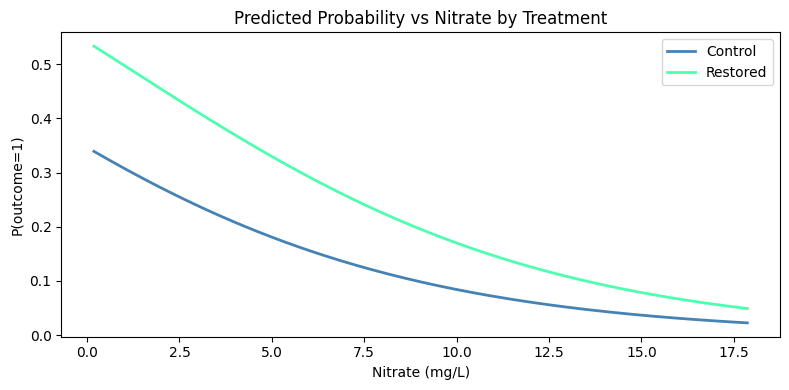

In [14]:
# Marginal effect: predicted probability across range of nitrate, holding others at mean
nitrate_range = np.linspace(nitrate.min(), nitrate.max(), 200)
fig, ax = plt.subplots(figsize=(8,4))
for trt, color, label in [(0,"steelblue","Control"),(1,"#4fffb0","Restored")]:
    Xp = pd.DataFrame({
        "const":      1,
        "elevation":  df["elevation"].mean(),
        "nitrate":    nitrate_range,
        "treatment":  trt
    })
    prob_pred = model.predict(Xp)
    ax.plot(nitrate_range, prob_pred, color=color, lw=2, label=label)
ax.set_xlabel("Nitrate (mg/L)"); ax.set_ylabel("P(outcome=1)")
ax.set_title("Predicted Probability vs Nitrate by Treatment")
ax.legend(); plt.tight_layout(); plt.show()

---
## Model Evaluation: ROC Curve and AUC

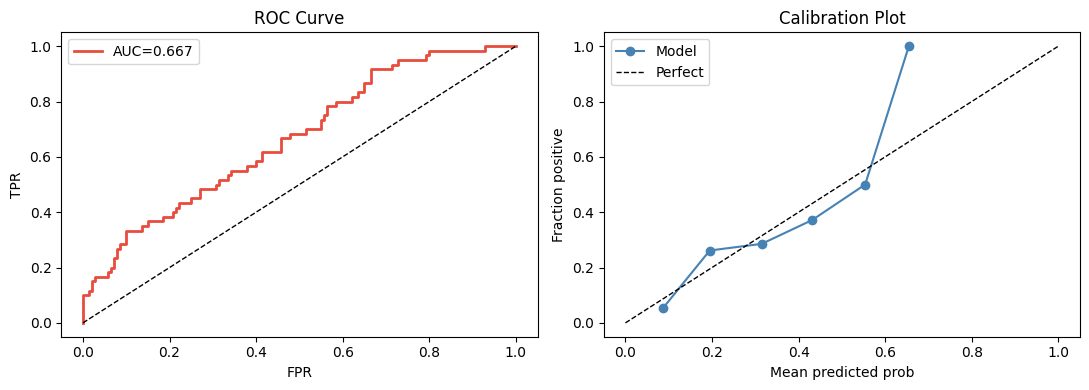

              precision    recall  f1-score   support

           0       0.73      0.94      0.82       140
           1       0.58      0.18      0.28        60

    accuracy                           0.71       200
   macro avg       0.65      0.56      0.55       200
weighted avg       0.68      0.71      0.66       200



In [15]:
y_pred_prob = model.predict(X)
fpr, tpr, thresholds = roc_curve(df["outcome"], y_pred_prob)
auc = roc_auc_score(df["outcome"], y_pred_prob)
fig, axes = plt.subplots(1,2,figsize=(11,4))
axes[0].plot(fpr, tpr, color="#e74c3c", lw=2, label=f"AUC={auc:.3f}")
axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve"); axes[0].legend()
# Calibration
from sklearn.calibration import calibration_curve
frac_pos, mean_pred = calibration_curve(df["outcome"], y_pred_prob, n_bins=8)
axes[1].plot(mean_pred, frac_pos, "o-", color="steelblue", label="Model")
axes[1].plot([0,1],[0,1],"k--",lw=1,label="Perfect")
axes[1].set_xlabel("Mean predicted prob"); axes[1].set_ylabel("Fraction positive")
axes[1].set_title("Calibration Plot"); axes[1].legend()
plt.tight_layout(); plt.show()
y_pred_class = (y_pred_prob >= 0.5).astype(int)
print(classification_report(df["outcome"], y_pred_class))

---
## Absolute Risk Differences

In [16]:
# Odds ratios are multiplied by odds, not probabilities -- ARD is more interpretable
baseline_p = model.predict(pd.DataFrame({
    "const": [1],
    "elevation": [df["elevation"].mean()],
    "nitrate": [df["nitrate"].mean()],
    "treatment": [0]
}))[0]
treated_p  = model.predict(pd.DataFrame({
    "const": [1],
    "elevation": [df["elevation"].mean()],
    "nitrate": [df["nitrate"].mean()],
    "treatment": [1]
}))[0]
ard = treated_p - baseline_p
rr  = treated_p / baseline_p
print(f"Control probability:   {baseline_p:.3f}")
print(f"Treatment probability: {treated_p:.3f}")
print(f"Absolute Risk Diff:    {ard:+.3f}")
print(f"Relative Risk:         {rr:.3f}")
or_val = np.exp(model.params["treatment"])
print(f"Odds Ratio:            {or_val:.3f}")
print("\nOR and RR diverge when baseline p is not small. Always report ARD alongside OR.")

Control probability:   0.204
Treatment probability: 0.363
Absolute Risk Diff:    +0.159
Relative Risk:         1.782
Odds Ratio:            2.227

OR and RR diverge when baseline p is not small. Always report ARD alongside OR.


---

## Common Pitfalls

**1. Reporting only odds ratios without predicted probabilities**  
An OR of 2.0 means the odds double, but the absolute probability change depends entirely on the baseline. OR=2.0 applied to a baseline of 1% gives 2%; applied to 50% gives 67%. Always report predicted probabilities and absolute risk differences.

**2. Treating the 0.5 threshold as optimal for classification**  
The default threshold of 0.5 minimises error only when classes are balanced and misclassification costs are equal. For imbalanced outcomes or asymmetric costs, select the threshold using the ROC curve based on the target FPR/TPR tradeoff.

**3. Using AUC as the only evaluation metric**  
AUC measures discrimination but not calibration. A model with AUC=0.85 may still assign systematically wrong probabilities. Always accompany AUC with a calibration plot.

**4. Ignoring complete separation**  
When a predictor perfectly predicts the outcome, maximum likelihood estimates do not exist and statsmodels returns very large coefficients with large SEs. Use Firth penalised logistic regression for small samples or near-perfect separation.

**5. Interpreting log-odds coefficients directly**  
Log-odds are not intuitive. Convert to odds ratios (exp(coef)) for multiplicative interpretation or to predicted probabilities for absolute interpretation. Report all three with confidence intervals.

---
*python_methods_library - Samantha McGarrigle*